In [2]:
import sys
from pathlib import Path

# Make the project's src/ folder importable, whether the notebook runs from
# the project root or from inside notebooks/.
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from src.data import load_features, load_activity_map

# The baseline uses the 561 pre-computed features.
X_train, y_train, subj_train = load_features("train")
X_test,  y_test,  subj_test  = load_features("test")

id_to_activity = load_activity_map()
class_names = [id_to_activity[i] for i in range(1, 7)]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Classes:", class_names)

X_train: (7352, 561) | X_test: (2947, 561)
y_train: (7352,) | y_test: (2947,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest = an ensemble of many decision trees, each trained on a random
# subset of data/features; they vote. Strong on tabular data, needs no scaling,
# and is a classic, honest baseline.
rf = RandomForestClassifier(
    n_estimators=300,   # number of trees (more = steadier, a bit slower)
    random_state=42,    # fixed seed so results are reproducible
    n_jobs=-1,          # use all CPU cores
)
rf.fit(X_train, y_train)

# Evaluate on the UNSEEN test subjects (the honest number).
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest test accuracy (unseen subjects): {acc:.4f}  ({acc*100:.2f}%)")

Random Forest test accuracy (unseen subjects): 0.9287  (92.87%)


In [4]:
from sklearn.metrics import classification_report, f1_score, recall_score

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

print(f"Macro-F1:     {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Macro-recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

                    precision    recall  f1-score   support

           WALKING      0.900     0.976     0.936       496
  WALKING_UPSTAIRS      0.904     0.915     0.909       471
WALKING_DOWNSTAIRS      0.968     0.857     0.909       420
           SITTING      0.912     0.886     0.899       491
          STANDING      0.897     0.921     0.909       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.929      2947
         macro avg      0.930     0.926     0.927      2947
      weighted avg      0.930     0.929     0.929      2947

Macro-F1:     0.927
Macro-recall: 0.926


Saved figure to: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\rf_confusion_matrix.png


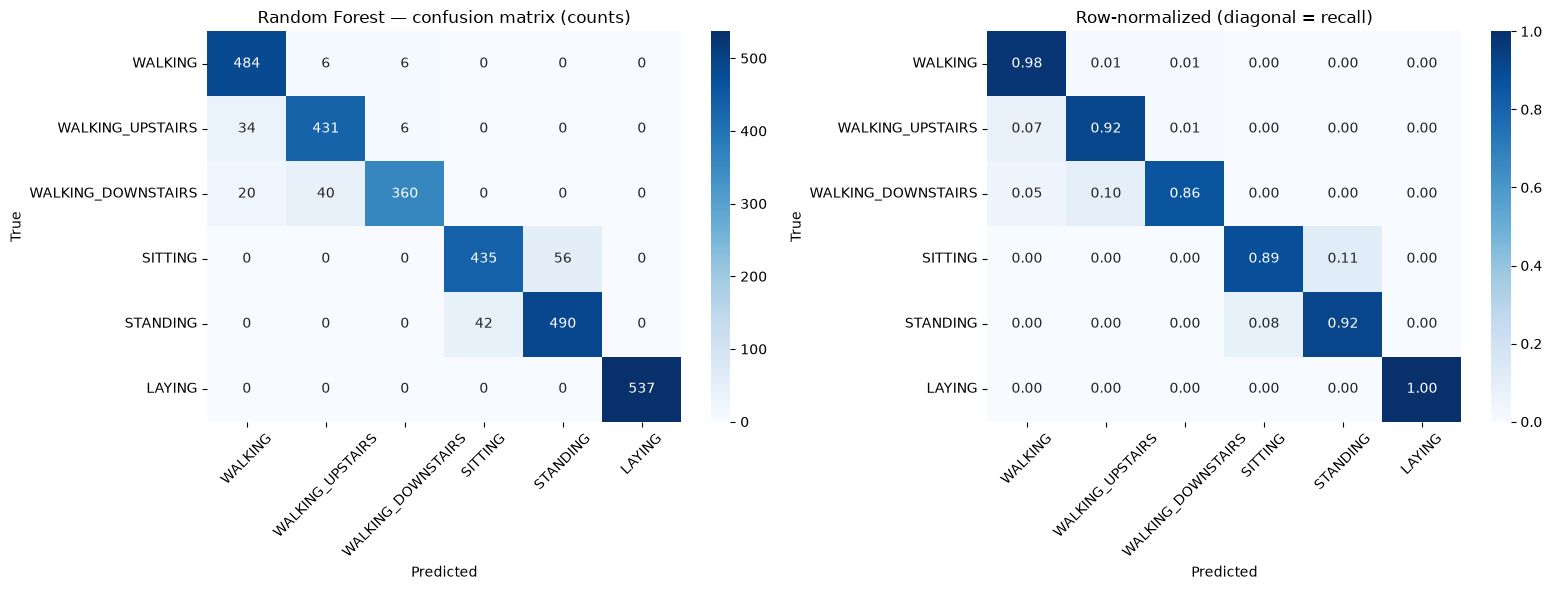

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm      = confusion_matrix(y_test, y_pred)                    # raw counts
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")  # row-normalized = recall per class

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Random Forest — confusion matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Row-normalized (diagonal = recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
out_path = fig_dir / "rf_confusion_matrix.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved figure to:", out_path.resolve())
plt.show()

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from src.data import load_raw_signals

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)

# Raw signals: (n, 128, 9). Labels/subjects reuse the arrays from the baseline cells.
Xtr_raw = load_raw_signals("train")
Xte_raw = load_raw_signals("test")
ytr = y_train - 1     # PyTorch CrossEntropyLoss expects class indices 0..5, not 1..6
yte = y_test - 1

# --- Per-channel standardization using TRAIN statistics ONLY (no leakage) ---
ch_mean = Xtr_raw.mean(axis=(0, 1))          # mean per channel -> shape (9,)
ch_std  = Xtr_raw.std(axis=(0, 1))           # std  per channel -> shape (9,)
Xtr_std = (Xtr_raw - ch_mean) / ch_std
Xte_std = (Xte_raw - ch_mean) / ch_std       # TEST uses TRAIN stats

print("After standardization (train) -> mean ~0, std ~1:",
      round(float(Xtr_std.mean()), 3), round(float(Xtr_std.std()), 3))

# --- Subject-wise validation split: hold out 4 whole training subjects ---
val_subjects = [27, 28, 29, 30]
val_mask   = np.isin(subj_train, val_subjects)
train_mask = ~val_mask
print(f"Fit windows: {train_mask.sum()} | Val windows: {val_mask.sum()} "
      f"| Val subjects held out: {val_subjects}")

Training device: cuda
After standardization (train) -> mean ~0, std ~1: -0.0 1.0
Fit windows: 5867 | Val windows: 1485 | Val subjects held out: [27, 28, 29, 30]


In [7]:
# --- Tensors in channels-first layout (n, 9, 128) that Conv1d expects ---
def to_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (n,128,9) -> (n,9,128)
    yt = torch.tensor(y, dtype=torch.long)
    return Xt, yt

Xfit_t, yfit_t = to_tensor(Xtr_std[train_mask], ytr[train_mask])
Xval_t, yval_t = to_tensor(Xtr_std[val_mask],   ytr[val_mask])
Xte_t,  yte_t  = to_tensor(Xte_std, yte)

train_loader = DataLoader(TensorDataset(Xfit_t, yfit_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xval_t, yval_t), batch_size=256)
test_loader  = DataLoader(TensorDataset(Xte_t,  yte_t),  batch_size=256)

xb, yb = next(iter(train_loader))
print("One batch -> X:", xb.shape, "y:", yb.shape)   # expect X: [64, 9, 128]

# --- The model: a 1-D CNN that learns features directly from the raw signals ---
class HAR_CNN(nn.Module):
    def __init__(self, n_channels=9, n_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),  # slide filters over time
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),                                       # 128 -> 64 timesteps
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),                                       # 64 -> 32 timesteps
            nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # global average over time -> (128, 1)
            nn.Flatten(),              # -> (128,)
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = HAR_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel on {device} | trainable parameters: {n_params:,}")
print(model)

One batch -> X: torch.Size([64, 9, 128]) y: torch.Size([64])

Model on cuda | trainable parameters: 49,478
HAR_CNN(
  (features): Sequential(
    (0): Conv1d(9, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): L

In [8]:
from copy import deepcopy

criterion = nn.CrossEntropyLoss()                          # standard multi-class loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # adaptive gradient descent
EPOCHS = 30

def evaluate(loader):
    """Return (avg_loss, accuracy) over a loader, without updating weights."""
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():                                  # no gradients = faster, less memory
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss_sum += criterion(out, yb).item() * xb.size(0)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += xb.size(0)
    return loss_sum / total, correct / total

best_val_acc, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss, seen = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()          # clear old gradients
        out  = model(xb)               # forward pass
        loss = criterion(out, yb)      # how wrong are we?
        loss.backward()                # backpropagate: compute gradients
        optimizer.step()               # update weights
        run_loss += loss.item() * xb.size(0); seen += xb.size(0)

    train_loss = run_loss / seen
    val_loss, val_acc = evaluate(val_loader)

    # Keep the weights that did best on the VALIDATION set (never the test set).
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch:2d} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f} | val_acc {val_acc:.3f}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")
model.load_state_dict(best_state)   # restore the best checkpoint for final test eval

Epoch  1 | train_loss 0.388 | val_loss 0.282 | val_acc 0.913
Epoch  2 | train_loss 0.134 | val_loss 0.265 | val_acc 0.920
Epoch  3 | train_loss 0.108 | val_loss 0.268 | val_acc 0.916
Epoch  4 | train_loss 0.096 | val_loss 0.361 | val_acc 0.901
Epoch  5 | train_loss 0.094 | val_loss 0.376 | val_acc 0.904
Epoch  6 | train_loss 0.099 | val_loss 0.472 | val_acc 0.909
Epoch  7 | train_loss 0.092 | val_loss 0.440 | val_acc 0.913
Epoch  8 | train_loss 0.083 | val_loss 0.488 | val_acc 0.902
Epoch  9 | train_loss 0.086 | val_loss 0.501 | val_acc 0.913
Epoch 10 | train_loss 0.082 | val_loss 0.539 | val_acc 0.913
Epoch 11 | train_loss 0.085 | val_loss 0.384 | val_acc 0.898
Epoch 12 | train_loss 0.083 | val_loss 0.485 | val_acc 0.904
Epoch 13 | train_loss 0.078 | val_loss 0.550 | val_acc 0.913
Epoch 14 | train_loss 0.088 | val_loss 0.300 | val_acc 0.921
Epoch 15 | train_loss 0.075 | val_loss 0.366 | val_acc 0.891
Epoch 16 | train_loss 0.083 | val_loss 0.446 | val_acc 0.900
Epoch 17 | train_loss 0.

<All keys matched successfully>

In [9]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
cnn_pred = np.concatenate(preds) + 1     # shift 0..5 back to 1..6 to match labels

cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1  = f1_score(y_test, cnn_pred, average="macro")
print(f"CNN  test accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%) | macro-F1: {cnn_f1:.3f}")
print(f"RF   test accuracy: 0.9287 (92.87%) | macro-F1: 0.927   <- baseline\n")

print(classification_report(y_test, cnn_pred, target_names=class_names, digits=3))

CNN  test accuracy: 0.9335 (93.35%) | macro-F1: 0.934
RF   test accuracy: 0.9287 (92.87%) | macro-F1: 0.927   <- baseline

                    precision    recall  f1-score   support

           WALKING      1.000     0.978     0.989       496
  WALKING_UPSTAIRS      0.910     0.962     0.935       471
WALKING_DOWNSTAIRS      0.940     0.974     0.957       420
           SITTING      0.906     0.823     0.862       491
          STANDING      0.863     0.921     0.891       532
            LAYING      0.990     0.950     0.970       537

          accuracy                          0.933      2947
         macro avg      0.935     0.934     0.934      2947
      weighted avg      0.935     0.933     0.933      2947



Saved figure to: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\cnn_confusion_matrix.png


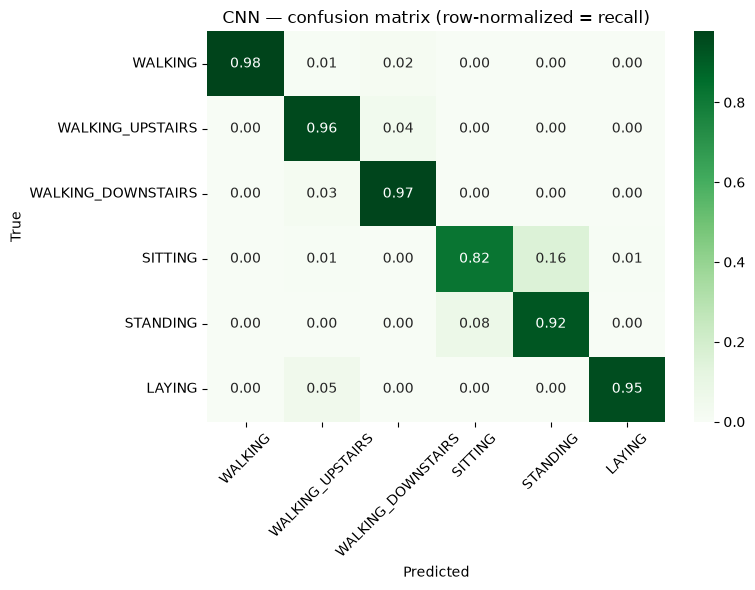

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_norm = confusion_matrix(y_test, cnn_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("CNN — confusion matrix (row-normalized = recall)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
out_path = fig_dir / "cnn_confusion_matrix.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved figure to:", out_path.resolve())
plt.show()

In [11]:
import torch.nn.functional as F

# 1) Random Forest probabilities on the test set. rf.classes_ is [1,2,3,4,5,6].
rf_proba = rf.predict_proba(X_test)                      # (2947, 6), columns = classes 1..6

# 2) CNN probabilities = softmax of its logits.
model.eval()
logits = []
with torch.no_grad():
    for xb, _ in test_loader:
        logits.append(model(xb.to(device)).cpu())
cnn_proba = F.softmax(torch.cat(logits), dim=1).numpy()  # (2947, 6), columns = classes 1..6

print("RF class order:", rf.classes_, "| CNN columns map to classes 1..6 -> aligned")

# 3) Soft-voting ensemble: average the two probability tables (equal weight).
ens_proba = (rf_proba + cnn_proba) / 2
ens_pred  = ens_proba.argmax(axis=1) + 1                 # back to 1..6

# 4) Compare all three models.
ens_acc = accuracy_score(y_test, ens_pred)
ens_f1  = f1_score(y_test, ens_pred, average="macro")
print(f"\n{'Model':<16}{'Accuracy':>10}{'Macro-F1':>11}")
print(f"{'Random Forest':<16}{0.9287:>10.4f}{0.927:>11.3f}")
print(f"{'CNN':<16}{cnn_acc:>10.4f}{cnn_f1:>11.3f}")
print(f"{'Ensemble':<16}{ens_acc:>10.4f}{ens_f1:>11.3f}")
print()
print(classification_report(y_test, ens_pred, target_names=class_names, digits=3))

RF class order: [1 2 3 4 5 6] | CNN columns map to classes 1..6 -> aligned

Model             Accuracy   Macro-F1
Random Forest       0.9287      0.927
CNN                 0.9335      0.934
Ensemble            0.9491      0.950

                    precision    recall  f1-score   support

           WALKING      1.000     0.992     0.996       496
  WALKING_UPSTAIRS      0.948     0.975     0.961       471
WALKING_DOWNSTAIRS      0.965     0.993     0.979       420
           SITTING      0.927     0.833     0.878       491
          STANDING      0.873     0.940     0.905       532
            LAYING      0.990     0.968     0.979       537

          accuracy                          0.949      2947
         macro avg      0.951     0.950     0.950      2947
      weighted avg      0.950     0.949     0.949      2947



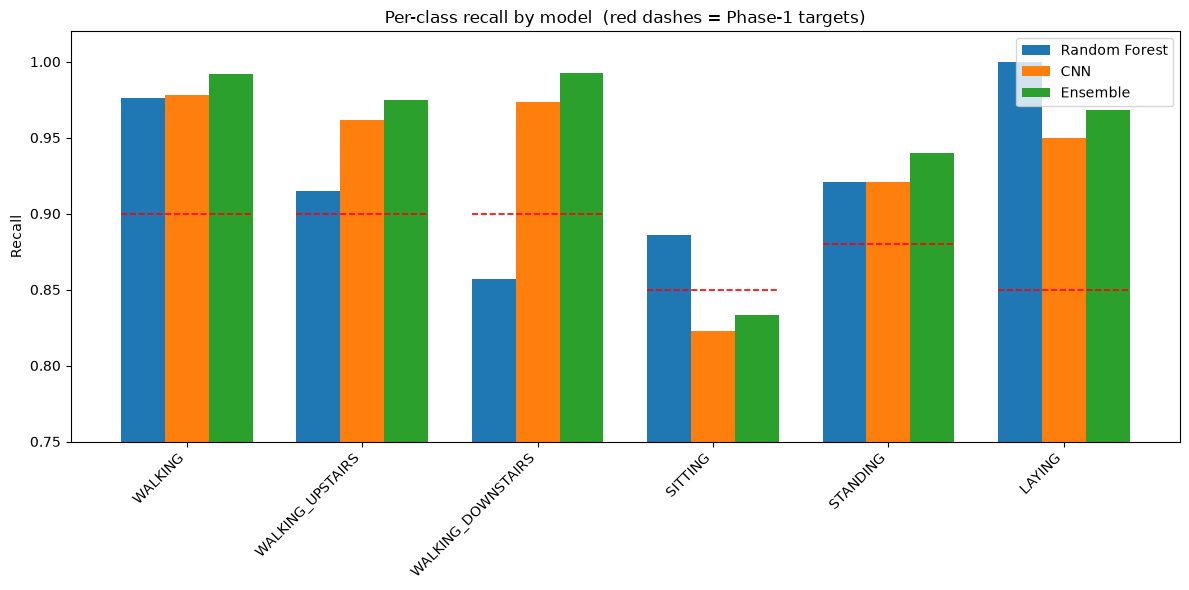

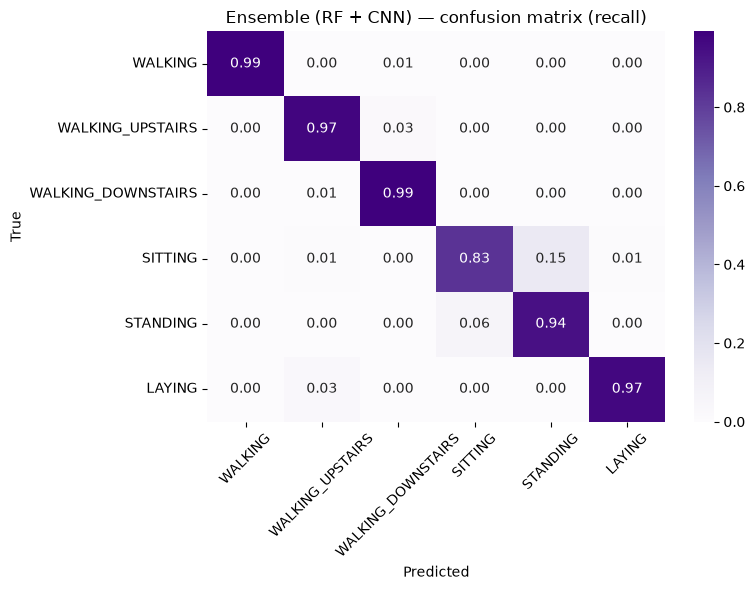

Saved model_recall_comparison.png and ensemble_confusion_matrix.png


In [12]:
from sklearn.metrics import recall_score, confusion_matrix

# Per-class recalls (order = classes 1..6 = class_names)
rf_rec  = recall_score(y_test, y_pred,   average=None)   # y_pred  = RF predictions
cnn_rec = recall_score(y_test, cnn_pred, average=None)
ens_rec = recall_score(y_test, ens_pred, average=None)
targets = [0.90, 0.90, 0.90, 0.85, 0.88, 0.85]          # your Phase-1 tiered targets

fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())

# --- Figure 1: grouped per-class recall comparison ---
x, w = np.arange(len(class_names)), 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, rf_rec,  w, label="Random Forest")
ax.bar(x,     cnn_rec, w, label="CNN")
ax.bar(x + w, ens_rec, w, label="Ensemble")
for i, t in enumerate(targets):                          # target markers
    ax.hlines(t, i - 1.5*w, i + 1.5*w, colors="red", linestyles="--", linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Recall"); ax.set_ylim(0.75, 1.02)
ax.set_title("Per-class recall by model  (red dashes = Phase-1 targets)")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / "model_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: ensemble confusion matrix ---
cm_norm = confusion_matrix(y_test, ens_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Ensemble (RF + CNN) — confusion matrix (recall)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig(fig_dir / "ensemble_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved model_recall_comparison.png and ensemble_confusion_matrix.png")

In [13]:
from sklearn.model_selection import GroupKFold, cross_validate

# Combine all 30 subjects for a robust, subject-wise estimate.
X_all      = np.vstack([X_train, X_test])
y_all      = np.concatenate([y_train, y_test])
groups_all = np.concatenate([subj_train, subj_test])   # subject id for each window
print("Full dataset:", X_all.shape, "| subjects:", len(np.unique(groups_all)))

# GroupKFold keeps every subject entirely inside ONE fold -> no subject leakage.
gkf   = GroupKFold(n_splits=5)
rf_cv = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

cv_res = cross_validate(rf_cv, X_all, y_all, groups=groups_all, cv=gkf,
                        scoring=["accuracy", "f1_macro"])

acc, f1 = cv_res["test_accuracy"], cv_res["test_f1_macro"]
print("Per-fold accuracy:", np.round(acc, 4))
print("Per-fold macro-F1:", np.round(f1, 4))
print(f"\nSubject-wise 5-fold CV (Random Forest):")
print(f"  Accuracy: {acc.mean():.4f} +/- {acc.std():.4f}")
print(f"  Macro-F1: {f1.mean():.4f} +/- {f1.std():.4f}")
print(f"\nReference: single fixed-split RF accuracy was 0.9287")

Full dataset: (10299, 561) | subjects: 30
Per-fold accuracy: [0.9226 0.9658 0.9617 0.9328 0.908 ]
Per-fold macro-F1: [0.9199 0.9641 0.9616 0.929  0.9033]

Subject-wise 5-fold CV (Random Forest):
  Accuracy: 0.9382 +/- 0.0224
  Macro-F1: 0.9356 +/- 0.0237

Reference: single fixed-split RF accuracy was 0.9287
